# Gradus: a small Transformer language model

Phase 3 functional-correctness demo: a decoder-only (GPT-style) `TransformerLM` trained as a char-level language model, entirely with Gradus's own autograd, attention, and Transformer-block implementations.

**Corpus:** a short set of original sentences written for this project (not excerpted from any existing text), shuffled and repeated so the model has real character/word-level statistical structure to learn rather than one string to memorize verbatim.

See `../docs/API.md` for the full API reference used below.

In [1]:
import time

import numpy as np

from gradus import Trainer
from gradus.nn import CrossEntropyLoss, TransformerLM
from gradus.optim import Adam

## Corpus

In [2]:
SENTENCES = [
    'the small fox runs across the quiet field.',
    'a curious robot explores the old library at night.',
    'waves crash gently on the sandy shore.',
    'bright stars appear over the sleeping town.',
    'a young student writes code until dawn.',
    'rain falls softly on the green hills.',
    'the cat naps beside a warm fire.',
    'new ideas grow from patient practice.',
    'the river flows past ancient stone walls.',
    'children laugh and play in the summer sun.',
    'a quiet garden blooms behind the house.',
    'the train moves slowly through misty mountains.',
    'birds sing before the morning light.',
    'an old clock ticks in the empty hall.',
    'friends share stories under the tall trees.',
]


def build_corpus(rng, repeats: int = 15) -> str:
    """Shuffle sentence order on each repeat so the model has to learn
    real statistical structure rather than one fixed sequence."""
    parts = []
    for _ in range(repeats):
        shuffled = list(SENTENCES)
        rng.shuffle(shuffled)
        parts.append(' '.join(shuffled))
    return ' '.join(parts)

In [3]:
np.random.seed(0)
rng = np.random.default_rng(0)

corpus = build_corpus(rng)
vocab = sorted(set(corpus))
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
token_ids = np.array([stoi[c] for c in corpus])

print(f'corpus length: {len(corpus)} chars, vocab size: {len(vocab)}')

corpus length: 9269 chars, vocab size: 26


## Model

In [4]:
seq_len = 32
model = TransformerLM(
    vocab_size=len(vocab), embed_dim=32, num_heads=4, ff_dim=64,
    num_layers=2, max_len=seq_len,
)
print(f'model parameters: {model.num_parameters():,}')

model parameters: 18,842


## Training

Each epoch draws a *fixed* number of random contiguous windows rather than covering the whole corpus -- with a from-scratch autograd engine, Python-level graph-construction overhead (not FLOPs) dominates cost, so step count, not corpus coverage, is what needs budgeting for a predictable runtime.

In [5]:
def make_batches(token_ids, seq_len, batch_size, steps, rng):
    n = len(token_ids) - seq_len - 1
    for _ in range(steps):
        batch_starts = rng.integers(0, n, size=batch_size)
        x = np.stack([token_ids[s : s + seq_len] for s in batch_starts])
        y = np.stack([token_ids[s + 1 : s + seq_len + 1] for s in batch_starts])
        yield x, y


class BatchesIterable:
    def __init__(self, gen_fn):
        self.gen_fn = gen_fn

    def __iter__(self):
        return self.gen_fn()

In [6]:
optimizer = Adam(model.parameters(), lr=3e-3)
loss_fn = CrossEntropyLoss()

def loss_wrapper(logits, targets):
    # CrossEntropyLoss expects (N, num_classes); flatten (batch, seq, vocab)
    # logits and (batch, seq) targets together. logits.reshape() is a
    # differentiable Tensor method, so gradients still flow correctly.
    flat_logits = logits.reshape(-1, logits.shape[-1])
    flat_targets = targets.reshape(-1)
    return loss_fn(flat_logits, flat_targets)

trainer = Trainer(model, optimizer, loss_wrapper)

In [7]:
epochs = 20
batch_size = 32
steps_per_epoch = 100  # ~2000 total steps
start = time.time()

def batches():
    return make_batches(token_ids, seq_len, batch_size, steps_per_epoch, rng)

def log_epoch(epoch, loss, metric):
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f'epoch {epoch + 1:2d}/{epochs}  loss={loss:.4f}')

history = trainer.fit(BatchesIterable(batches), epochs=epochs, on_epoch_end=log_epoch)
elapsed = time.time() - start

print(f'\ntraining time: {elapsed:.1f}s ({epochs} epochs, CPU)')
print(f'initial loss: {history["loss"][0]:.4f}')
print(f'final loss: {history["loss"][-1]:.4f}')

epoch  1/20  loss=2.5911


epoch  2/20  loss=1.7636


epoch  4/20  loss=0.4060


epoch  6/20  loss=0.2661


epoch  8/20  loss=0.2386


...

epoch 12/20  loss=0.2128


epoch 14/20  loss=0.2055


epoch 16/20  loss=0.2023


epoch 18/20  loss=0.1960


epoch 20/20  loss=0.1931

training time: 87.2s (20 epochs, CPU)
initial loss: 2.5911
final loss: 0.1931


## Convergence plot

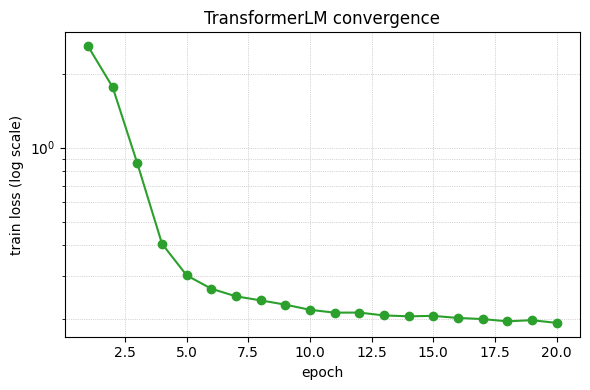

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), history['loss'], marker='o', color='tab:green')
ax.set_xlabel('epoch')
ax.set_ylabel('train loss (log scale)')
ax.set_yscale('log')
ax.set_title('TransformerLM convergence')
ax.grid(True, which='both', linestyle=':', linewidth=0.5)
fig.tight_layout()
plt.show()

## Sample generation

Illustrative only (temperature-scaled multinomial sampling), not a correctness metric -- the gradient-check suite and the loss curve above are the actual evidence.

In [9]:
def generate(model, stoi, itos, prompt, length, seq_len, rng):
    token_ids = [stoi[c] for c in prompt]
    for _ in range(length):
        context = token_ids[-seq_len:]
        x = np.array([context])
        logits = model(x)
        last_logits = logits.data[0, -1]
        probs = np.exp(last_logits - last_logits.max())
        probs /= probs.sum()
        next_id = rng.choice(len(probs), p=probs)
        token_ids.append(int(next_id))
    return ''.join(itos[i] for i in token_ids)

model.eval()
sample = generate(model, stoi, itos, prompt='the ', length=80, seq_len=seq_len, rng=rng)
print(repr(sample))

'the old library at night. waves crash gently on the sandy shore. rain falls softly o'
